# Regression and Clustering

Linear regression — predict `child_mortality_rate` from fertility and time
K-Means clustering — group countries by demographic-transition profile


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('Dataset/dataset_countries.csv')
df = df[df['year'] >= 1950].copy()
print(f'Shape: {df.shape}')
df.head()


Shape: (17390, 7)


,entity,code,year,child_mortality_rate,fertility_rate_hist,continent,sub_region
0,Afghanistan,AFG,1950,37.13,7.248,Asia,Southern Asia
1,Afghanistan,AFG,1951,37.13,7.260,Asia,Southern Asia
2,Afghanistan,AFG,1952,37.13,7.260,Asia,Southern Asia
3,Afghanistan,AFG,1953,37.13,7.266,Asia,Southern Asia
4,Afghanistan,AFG,1954,37.13,7.254,Asia,Southern Asia


## 1. Linear Regression

Predict `child_mortality_rate` from demographic and temporal features.

**Simple** — only `fertility_rate_hist` as predictor
**Multiple** — `fertility_rate_hist` + `year`

Evaluation: 80/20 train-test split, metrics R², RMSE, MAE.


In [2]:
reg_df = df[['fertility_rate_hist', 'year', 'child_mortality_rate']].dropna().copy()
y = reg_df['child_mortality_rate']

X_simple   = reg_df[['fertility_rate_hist']]
X_multiple = reg_df[['fertility_rate_hist', 'year']]

X_s_train, X_s_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)
X_m_train, X_m_test, _, _ = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42)

print(f'Train size: {len(y_train)}  |  Test size: {len(y_test)}')


Train size: 13912  |  Test size: 3478


In [3]:
def evaluate(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f'--- {name} ---')
    print(f'  coefficients : {dict(zip(X_train.columns, np.round(model.coef_, 4)))}')
    print(f'  intercept    : {model.intercept_:.4f}')
    print(f'  R²  (test)   : {r2:.4f}')
    print(f'  RMSE (test)  : {rmse:.4f}')
    print(f'  MAE  (test)  : {mae:.4f}\n')
    return model, y_pred

model_simple,   y_pred_simple   = evaluate('Simple  (fertility only)',
    LinearRegression(), X_s_train, X_s_test, y_train, y_test)
model_multiple, y_pred_multiple = evaluate('Multiple (fertility + year)',
    LinearRegression(), X_m_train, X_m_test, y_train, y_test)


--- Simple  (fertility only) ---
  coefficients : {'fertility_rate_hist': np.float64(3.0532)}
  intercept    : -3.4625
  R²  (test)   : 0.5491
  RMSE (test)  : 5.6735
  MAE  (test)  : 3.8700

--- Multiple (fertility + year) ---
  coefficients : {'fertility_rate_hist': np.float64(2.7251), 'year': np.float64(-0.0598)}
  intercept    : 116.6371
  R²  (test)   : 0.5632
  RMSE (test)  : 5.5841
  MAE  (test)  : 3.8176



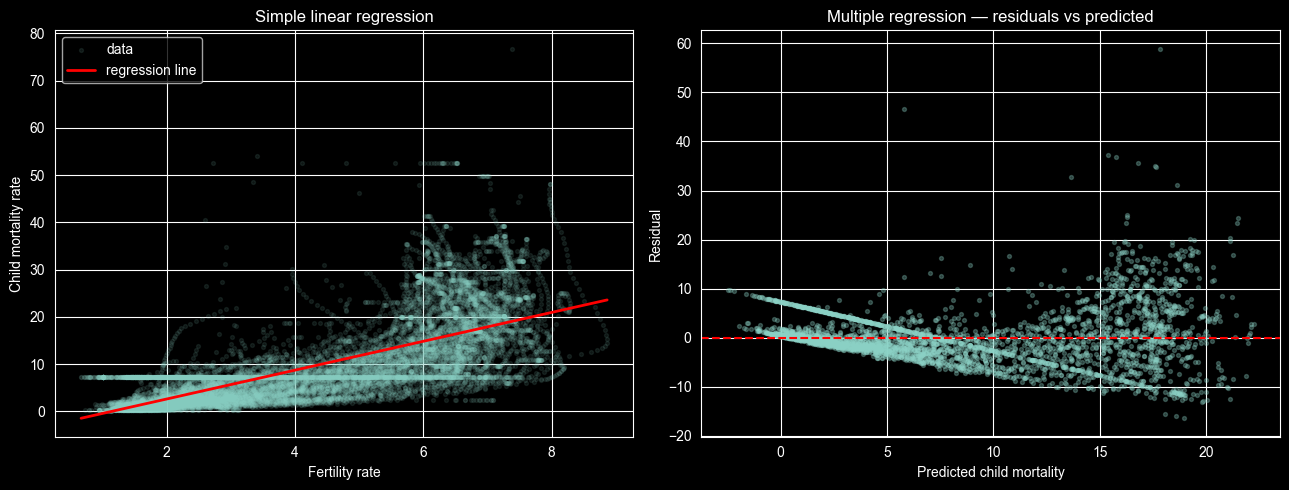

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: simple regression line on full data
x_line = pd.DataFrame({'fertility_rate_hist': np.linspace(
    reg_df['fertility_rate_hist'].min(),
    reg_df['fertility_rate_hist'].max(), 100)})
y_line = model_simple.predict(x_line)
axes[0].scatter(reg_df['fertility_rate_hist'], y, alpha=0.1, s=8, label='data')
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='regression line')
axes[0].set_xlabel('Fertility rate')
axes[0].set_ylabel('Child mortality rate')
axes[0].set_title('Simple linear regression')
axes[0].legend()

# Plot 2: residuals of the multiple model
residuals = y_test - y_pred_multiple
axes[1].scatter(y_pred_multiple, residuals, alpha=0.3, s=8)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted child mortality')
axes[1].set_ylabel('Residual')
axes[1].set_title('Multiple regression — residuals vs predicted')

plt.tight_layout()
plt.show()


**Conclusion — Linear Regression**

Adding `year` to the model increases the explanatory power because mortality drops
over time even after controlling for fertility (medical progress, sanitation, etc.).
The residual plot shows a funnel/curved shape: errors grow for higher predicted
values, which suggests the relationship is **not strictly linear** — a log-transform of
`child_mortality_rate` or polynomial features would likely improve fit.


## 2. Clustering

group countries by demographic-transition profile.

Each country becomes one observation with three features:
1. Mean fertility (1950–2023)
2. Mean child mortality (1950–2023)
3. Change in mortality between the 1950s decade and the 2010s decade
   (captures the speed of the demographic transition)

Features are standardised; K is chosen with the elbow rule + silhouette score.


In [5]:
def decade_mean(group, start, end, col):
    sub = group[(group['year'] >= start) & (group['year'] <= end)]
    return sub[col].mean()

profiles = []
for entity, group in df.groupby('entity'):
    mort_1950s = decade_mean(group, 1950, 1959, 'child_mortality_rate')
    mort_2010s = decade_mean(group, 2010, 2019, 'child_mortality_rate')
    profiles.append({
        'entity'         : entity,
        'continent'      : group['continent'].iloc[0],
        'mean_fertility' : group['fertility_rate_hist'].mean(),
        'mean_mortality' : group['child_mortality_rate'].mean(),
        'mortality_drop' : mort_1950s - mort_2010s,
    })

country_df = pd.DataFrame(profiles).dropna()
print(f'Countries with complete profile: {len(country_df)}')
country_df.head()


Countries with complete profile: 235


,entity,continent,mean_fertility,mean_mortality,mortality_drop
0,Afghanistan,Asia,7.028716,21.598243,29.492
1,Albania,Europe,3.596122,5.622432,8.579
2,Algeria,Africa,5.246784,12.214189,21.580
3,American Samoa,Oceania,4.602784,7.303750,0.000
4,Andorra,Europe,1.779919,1.204730,1.351


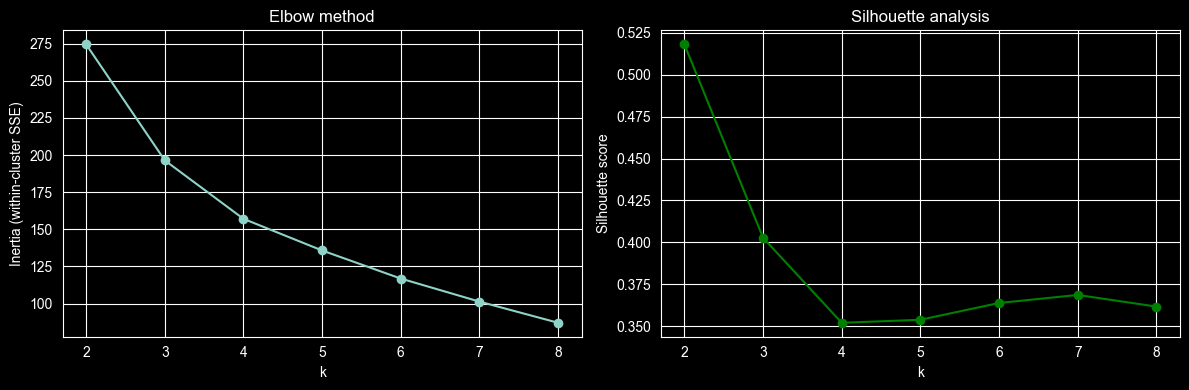

Best k by silhouette: 2


In [6]:
features = ['mean_fertility', 'mean_mortality', 'mortality_drop']
X = country_df[features].values
X_scaled = StandardScaler().fit_transform(X)

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouettes, marker='o', color='green')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f'Best k by silhouette: {best_k}')


Cluster profiles:
         mean_fertility  mean_mortality  mortality_drop  n_countries
cluster                                                             
0                  6.20           20.18           23.81           36
1                  4.11            6.12            8.37           63
2                  4.99           11.51           20.46           53
3                  2.26            3.84            4.20           83

Example countries by cluster:
  cluster 0: ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cambodia']
  cluster 1: ['Albania', 'American Samoa', 'Azerbaijan', 'Belize', 'Brunei', 'Chile']
  cluster 2: ['Algeria', 'Bahrain', 'Bangladesh', 'Bhutan', 'Bolivia', 'Botswana']
  cluster 3: ['Andorra', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba']


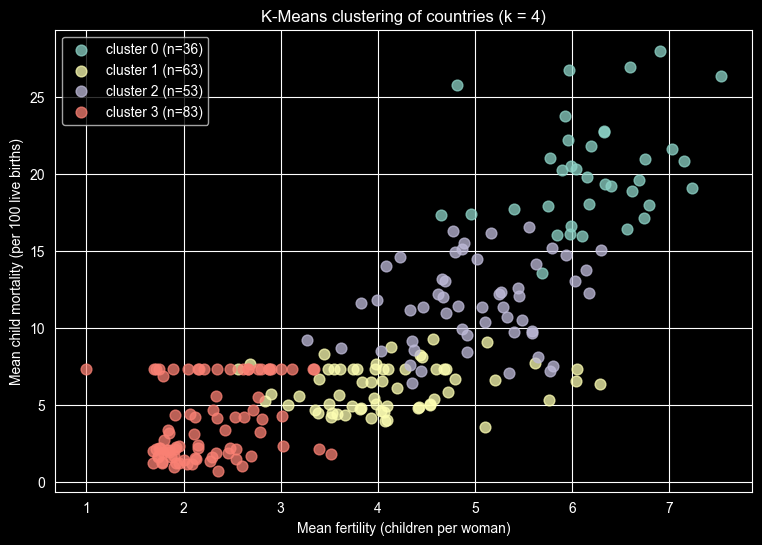

In [7]:
k = 4  # chosen for interpretability after elbow/silhouette inspection
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
country_df['cluster'] = kmeans.labels_

# Cluster summary (back in original units)
summary = country_df.groupby('cluster')[features].mean().round(2)
summary['n_countries'] = country_df.groupby('cluster').size()
print('Cluster profiles:')
print(summary)

# Sample countries per cluster
print('\nExample countries by cluster:')
for c in range(k):
    sample = country_df[country_df['cluster'] == c]['entity'].head(6).tolist()
    print(f'  cluster {c}: {sample}')

# 2D visualisation in the fertility x mortality plane
plt.figure(figsize=(9, 6))
for c in range(k):
    sub = country_df[country_df['cluster'] == c]
    plt.scatter(sub['mean_fertility'], sub['mean_mortality'],
                label=f'cluster {c} (n={len(sub)})', alpha=0.75, s=60)
plt.xlabel('Mean fertility (children per woman)')
plt.ylabel('Mean child mortality (per 100 live births)')
plt.title(f'K-Means clustering of countries (k = {k})')
plt.legend()
plt.show()


**Conclusion — Clustering**

K-Means with k = 4 produces interpretable groups along the demographic-transition axis:
low-fertility/low-mortality industrial countries on one end, high-fertility/high-mortality
Sub-Saharan countries on the other, and intermediate transition profiles in between.
The third feature (`mortality_drop`) separates countries that transitioned quickly from
those that did not, even when their current averages look similar.
